# Trabalho Final
Guilherme Kastner

## Análise de dados de princesas da Disney

Dados retirados do kaggle.com

https://www.kaggle.com/code/sonawanelalitsunil/disney-princess-popularity-ml-56-67

Se trata de uma base fictícia com uma busca de indicação de dados para análise da história de que a base deseja contar

In [81]:
# importação das bibliotecas de manipulação de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importação dos dados do arquivo CSV
df = pd.read_csv('disney_princess_popularity_dataset_300_rows.csv', sep=',')
# exibição das primeiras linhas do DataFrame
df.head()

,PrincessName,FirstMovieTitle,FirstMovieYear,MovieRuntimeMinutes,NumberOfSongs,HasSoloSong,HasDuet,HairColor,EyeColor,OutfitPrimaryColor,...,RottenTomatoesScore,BoxOfficeMillions,AvgScreenTimeMinutes,NumMerchItemsOnAmazon,GoogleSearchIndex2024,InstagramFanPages,TikTokHashtagViewsMillions,Top3Hashtags,IsIconic,PopularityScore
0,Pocahontas,Pocahontas's Adventure,1977,85,4,No,Yes,Brown,Green,Pink,...,88,661,25,2524,68,298,481,#TeamPocahontas #LovePocahontas #PocahontasFor...,Yes,88
1,Mulan,Mulan's Adventure,1995,85,1,Yes,Yes,Blonde,Brown,Purple,...,91,688,52,4202,49,133,619,#TeamMulan #LoveMulan #MulanForever,Yes,78
2,Raya,Raya's Adventure,1989,110,4,No,No,Blonde,Hazel,Pink,...,76,790,54,525,68,129,230,#TeamRaya #LoveRaya #RayaForever,No,53
3,Anna,Anna's Adventure,1940,78,1,No,No,Brown,Grey,Green,...,70,820,42,1951,73,138,697,#TeamAnna #LoveAnna #AnnaForever,Yes,84
4,Mulan,Mulan's Adventure,1943,103,7,No,Yes,White,Brown,Green,...,86,996,55,3958,34,155,200,#TeamMulan #LoveMulan #MulanForever,Yes,71


## Análise de qualidade de dados

In [82]:
# Exibição de quantidade de linhas e colunas do DataFrame
print(f'O DataFrame possui {df.shape[0]} linhas e {df.shape[1]} colunas.')

O DataFrame possui 300 linhas e 36 colunas.


In [83]:
# Exibição dos tipos de dados de cada coluna
print('\nTipos de dados de cada coluna:')
print(df.dtypes)


Tipos de dados de cada coluna:
PrincessName                   object
FirstMovieTitle                object
FirstMovieYear                  int64
MovieRuntimeMinutes             int64
NumberOfSongs                   int64
HasSoloSong                    object
HasDuet                        object
HairColor                      object
EyeColor                       object
OutfitPrimaryColor             object
OutfitStyleEra                 object
IsRoyalByBirth                 object
HasAnimalSidekick              object
SidekickType                   object
HasMagicalPowers               object
MagicType                      object
MainSetting                    object
IsBasedOnRealStory             object
CulturalOrigin                 object
SpeaksToAnimals                object
FightsVillainDirectly          object
RomanticSubplot                object
MarriedByEnd                   object
VillainName                    object
VillainType                    object
IMDB_Rating       

In [84]:
# Análise de valores nulos no DataFrame
print('\nValores nulos em cada coluna:')
print(df.isnull().sum())


Valores nulos em cada coluna:
PrincessName                   0
FirstMovieTitle                0
FirstMovieYear                 0
MovieRuntimeMinutes            0
NumberOfSongs                  0
HasSoloSong                    0
HasDuet                        0
HairColor                      0
EyeColor                       0
OutfitPrimaryColor             0
OutfitStyleEra                 0
IsRoyalByBirth                 0
HasAnimalSidekick              0
SidekickType                  70
HasMagicalPowers               0
MagicType                     53
MainSetting                    0
IsBasedOnRealStory             0
CulturalOrigin                 0
SpeaksToAnimals                0
FightsVillainDirectly          0
RomanticSubplot                0
MarriedByEnd                   0
VillainName                    0
VillainType                   47
IMDB_Rating                    0
RottenTomatoesScore            0
BoxOfficeMillions              0
AvgScreenTimeMinutes           0
NumMerchItem

In [85]:
# Eliminação das colunas com dados faltantes, uma vez que não são relevantes para a análise
# colunas vilain type, sidekick type e magic type
df.drop(columns=['VillainType', 'SidekickType', 'MagicType'], inplace=True)
# Exibição das colunas com dados faltantes
print('\nColunas com dados faltantes após eliminação:')
print(df.isnull().sum())



Colunas com dados faltantes após eliminação:
PrincessName                  0
FirstMovieTitle               0
FirstMovieYear                0
MovieRuntimeMinutes           0
NumberOfSongs                 0
HasSoloSong                   0
HasDuet                       0
HairColor                     0
EyeColor                      0
OutfitPrimaryColor            0
OutfitStyleEra                0
IsRoyalByBirth                0
HasAnimalSidekick             0
HasMagicalPowers              0
MainSetting                   0
IsBasedOnRealStory            0
CulturalOrigin                0
SpeaksToAnimals               0
FightsVillainDirectly         0
RomanticSubplot               0
MarriedByEnd                  0
VillainName                   0
IMDB_Rating                   0
RottenTomatoesScore           0
BoxOfficeMillions             0
AvgScreenTimeMinutes          0
NumMerchItemsOnAmazon         0
GoogleSearchIndex2024         0
InstagramFanPages             0
TikTokHashtagViewsMillions

## Análise de dados preliminares sobre as princesas

Quais princesas tem mais filmes e recorrências

In [86]:
# Criação de um dataframe para análise de dados de princesas
# colunas nome, filme mais recente e quantidade de filmes
princess_df = df[['PrincessName', 'FirstMovieTitle', 'FirstMovieYear']].copy()

# Montagem de um novo dataframe contando quantas vezes cada princesa aparece
princess_count_df = princess_df.groupby('PrincessName').size().reset_index(name='Count')

# Exibição do novo DataFrame (agora o correto)
print('\nNovo DataFrame com dados de princesas:')
print(princess_count_df.head())




Novo DataFrame com dados de princesas:
  PrincessName  Count
0         Anna     23
1        Ariel     20
2       Aurora     18
3        Belle     20
4   Cinderella     21


C:\Users\gkr14\AppData\Local\Temp\ipykernel_40940\1491093454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='PrincessName', data=princess_count_df, palette='viridis')


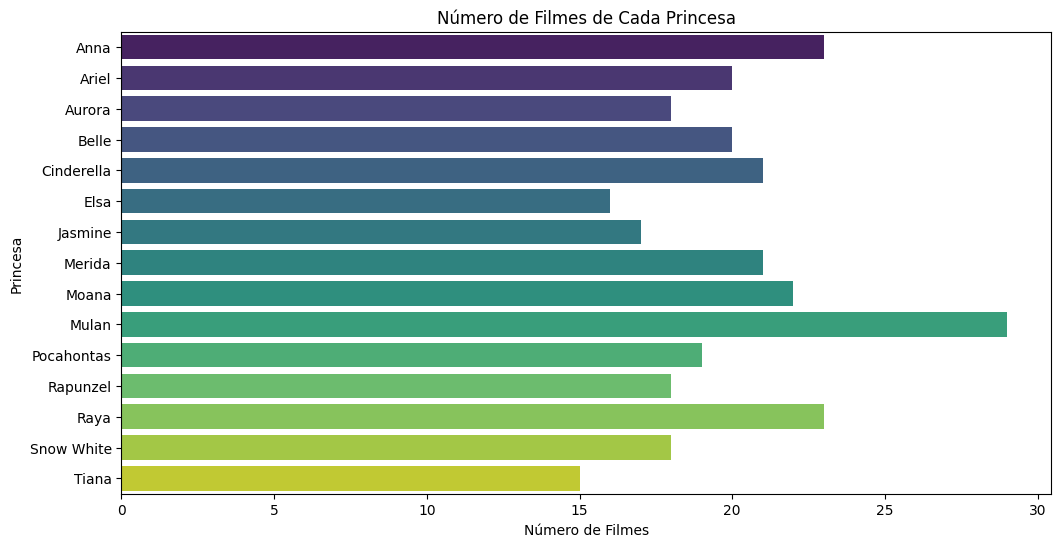

In [87]:
# Montagem de um gráfico de barras com o número de filmes de cada princesa
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='PrincessName', data=princess_count_df, palette='viridis')
plt.title('Número de Filmes de Cada Princesa')
plt.xlabel('Número de Filmes')
plt.ylabel('Princesa')
plt.show()

Mesmo a Mulan sendo uma princesa de etnia oriental, ela foi a que mais tinha filmes próprios.

## Sobre a etnia representada das princesas

Historicamente, se fala que as princesas são representadas por um padrão de beleza estilo Barbie

- Loira
- Olho claro

Vamos analisar isso de acordo com a base de dados completa, mesmo com algumas personagens podendo ter a sua etnia alterada ao longo do tempo

In [88]:
# Reutilização do primeiro DataFrame para análise de etnia das princesas
# Criação de um novo DataFrame com as colunas relevantes para a análise de etnia
princess_ethnicity_df = df[['PrincessName', 'CulturalOrigin', 'HairColor', 'EyeColor']].copy()

# Exibição do novo DataFrame (agora o correto)
print('\nNovo DataFrame com dados de etnia das princesas:')
print(princess_ethnicity_df.head())


Novo DataFrame com dados de etnia das princesas:
  PrincessName   CulturalOrigin HairColor EyeColor
0   Pocahontas         Scottish     Brown    Green
1        Mulan  Native American    Blonde    Brown
2         Raya       Polynesian    Blonde    Hazel
3         Anna         Scottish     Brown     Grey
4        Mulan          Arabian     White    Brown


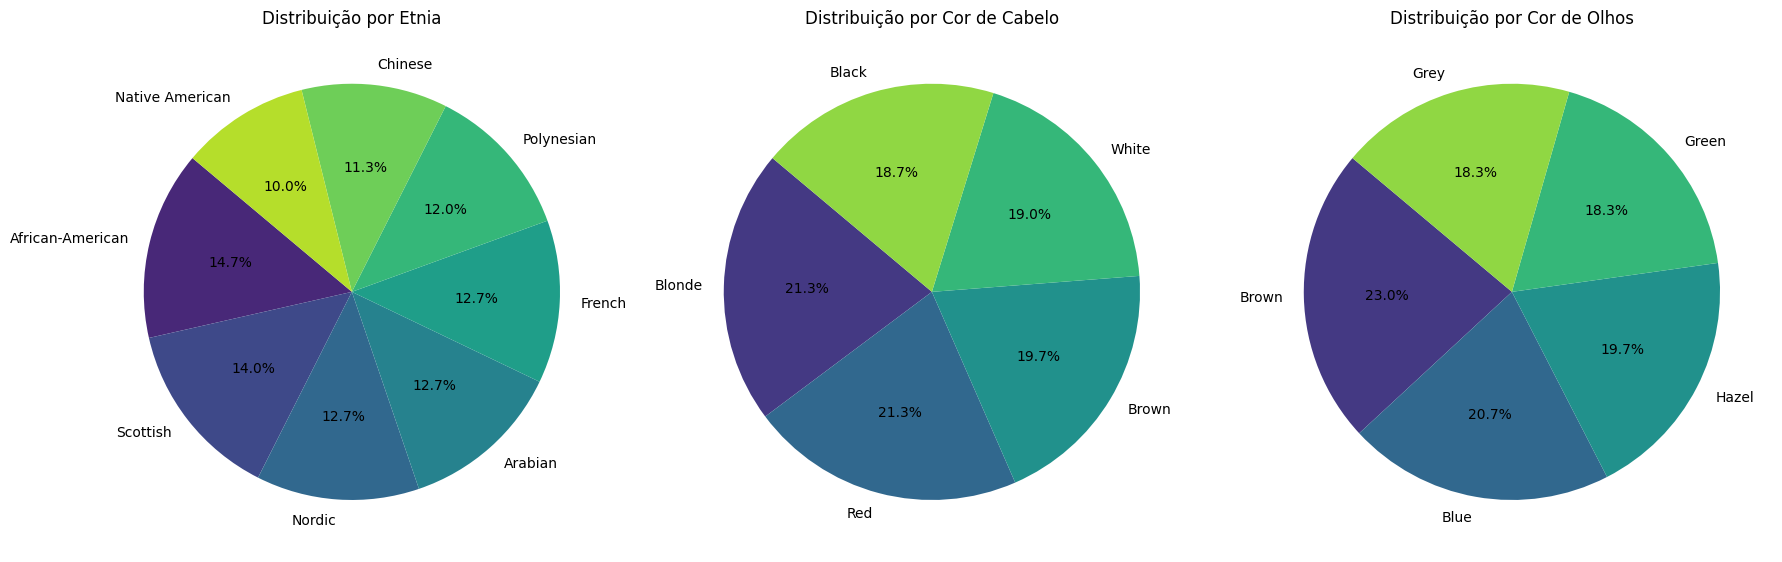

In [89]:
# Criação de um gráfico de barras para visualizar a contagem de princesas
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Lista com as colunas que queremos analisar
caracteristicas = ['CulturalOrigin', 'HairColor', 'EyeColor']
titulos = ['Distribuição por Etnia', 'Distribuição por Cor de Cabelo', 'Distribuição por Cor de Olhos']

# Loop para criar um gráfico de pizza para cada característica
for i, caracteristica in enumerate(caracteristicas):
    dados = princess_ethnicity_df[caracteristica].value_counts(normalize=True) * 100
    
    # Gerar uma paleta de cores baseada na quantidade de categorias
    cores = sns.color_palette('viridis', len(dados))
    
    # Criar o gráfico de pizza
    axs[i].pie(dados, labels=dados.index, autopct='%1.1f%%', startangle=140, colors=cores)
    axs[i].set_title(titulos[i])

plt.tight_layout()
plt.show()




Claramente há uma diversidade bem grande em diversos aspectos

- Etnia
- Cor de cabelos
- Cor dos olhos

Uma grande representatividade de acordo com o dataset ofertado

## Sobre popularidade

Montagem de uma listagem dos 20 filmes de princesas mais populares no Rotten Tomatoes

In [90]:
# Criação de um novo DataFrame para análise de popularidade no rotten tomatoes
# reutilização do primeiro DataFrame para análise de popularidade no rotten tomatoes
# Criação de um novo DataFrame com as colunas relevantes para a análise de popularidade

popularity_df = df[['PrincessName', 'FirstMovieTitle', 'FirstMovieYear', 'RottenTomatoesScore', 'PopularityScore']].copy()

# Manter no dataframe apenas os 20 filmes mais bem avaliados
popularity_df = popularity_df.nlargest(20, 'RottenTomatoesScore').copy()
# Exibição do novo DataFrame (agora o correto)
print('\nNovo DataFrame com os 20 filmes mais bem avaliados:')
print(popularity_df.head())



Novo DataFrame com os 20 filmes mais bem avaliados:
    PrincessName       FirstMovieTitle  FirstMovieYear  RottenTomatoesScore  \
166     Rapunzel  Rapunzel's Adventure            1961                  100   
196        Ariel     Ariel's Adventure            2003                  100   
8           Anna      Anna's Adventure            2007                   99   
64      Rapunzel  Rapunzel's Adventure            1961                   99   
68         Mulan     Mulan's Adventure            2001                   99   

     PopularityScore  
166               70  
196               76  
8                 82  
64                62  
68                84  


In [91]:
# Validação do tamanho do DataFrame
print(f'\nO DataFrame possui {popularity_df.shape[0]} linhas e {popularity_df.shape[1]} colunas.')


O DataFrame possui 20 linhas e 5 colunas.


In [92]:
# vamos atualizar o dataframe para que o firstmovie title concatene o seu valor com o first movie year
popularity_df['FirstMovieTitle'] = popularity_df['FirstMovieTitle'] + ' (' + popularity_df['FirstMovieYear'].astype(str) + ')'
# Exibição do novo DataFrame (agora o correto)
print('\nNovo DataFrame com os 20 filmes mais bem avaliados e ano de lançamento:')
print(popularity_df.head())


Novo DataFrame com os 20 filmes mais bem avaliados e ano de lançamento:
    PrincessName              FirstMovieTitle  FirstMovieYear  \
166     Rapunzel  Rapunzel's Adventure (1961)            1961   
196        Ariel     Ariel's Adventure (2003)            2003   
8           Anna      Anna's Adventure (2007)            2007   
64      Rapunzel  Rapunzel's Adventure (1961)            1961   
68         Mulan     Mulan's Adventure (2001)            2001   

     RottenTomatoesScore  PopularityScore  
166                  100               70  
196                  100               76  
8                     99               82  
64                    99               62  
68                    99               84  


C:\Users\gkr14\AppData\Local\Temp\ipykernel_40940\2319154636.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RottenTomatoesScore', y='FirstMovieTitle', data=top20_df, palette='viridis')


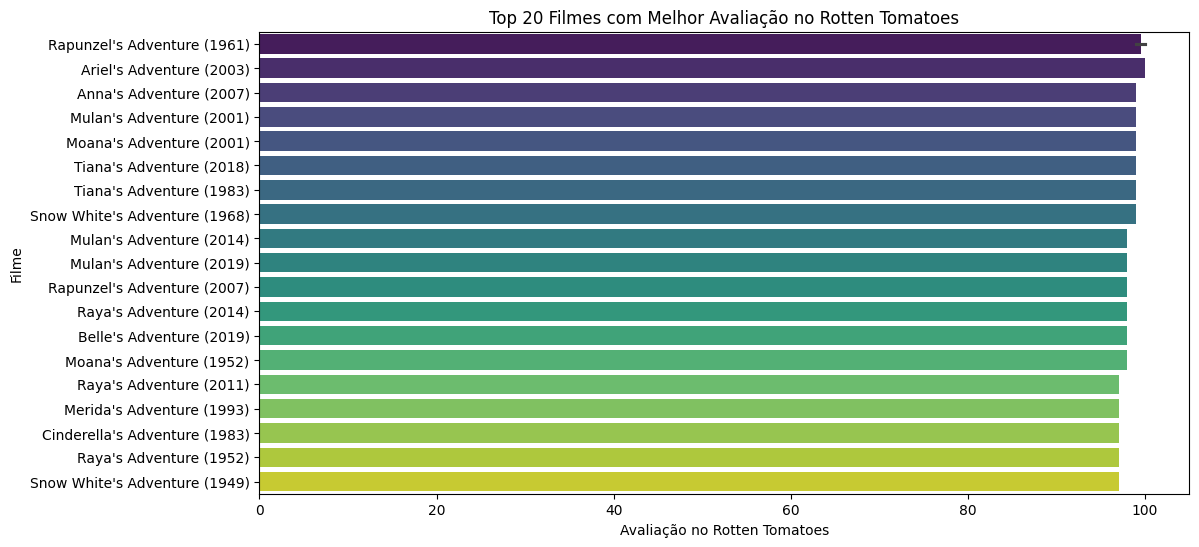

In [93]:
# Ordenar o DataFrame por RottenTomatoesScore em ordem decrescente
popularity_df = popularity_df.sort_values(by='RottenTomatoesScore', ascending=False)

# Pegar apenas os 20 primeiros filmes
top20_df = popularity_df.head(20)

# Criação de um gráfico de barras para visualizar o score de popularidade
plt.figure(figsize=(12, 6))
sns.barplot(x='RottenTomatoesScore', y='FirstMovieTitle', data=top20_df, palette='viridis')
plt.title('Top 20 Filmes com Melhor Avaliação no Rotten Tomatoes')
plt.xlabel('Avaliação no Rotten Tomatoes')
plt.ylabel('Filme')
plt.show()

Entre os filmes mais bem avaliados, há uma dispersão de eras do cinema, assim como princesas